In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

import pickle

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv(
    "Leukemia_GSE9476.csv"
)

In [6]:
df.head()

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Hs28SrRNA-5_at,AFFX-r2-Hs28SrRNA-M_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,1,Bone_Marrow_CD34,7.745245,7.811210,6.477916,8.841506,4.546941,7.957714,5.344999,4.673364,...,5.058849,6.810004,12.800060,12.718612,5.391512,4.666166,3.974759,3.656693,4.160622,4.139249
1,12,Bone_Marrow_CD34,8.087252,7.240673,8.584648,8.983571,4.548934,8.011652,5.579647,4.828184,...,4.436153,6.751471,12.472706,12.333593,5.379738,4.656786,4.188348,3.792535,4.204414,4.122700
2,13,Bone_Marrow_CD34,7.792056,7.549368,11.053504,8.909703,4.549328,8.237099,5.406489,4.615572,...,4.392061,6.086295,12.637384,12.499038,5.316604,4.600566,3.845561,3.635715,4.174199,4.067152
3,14,Bone_Marrow_CD34,7.767265,7.094460,11.816433,8.994654,4.697018,8.283412,5.582195,4.903684,...,4.633334,6.375991,12.903630,12.871454,5.179951,4.641952,3.991634,3.704587,4.149938,3.910150
4,15,Bone_Marrow_CD34,8.010117,7.405281,6.656049,9.050682,4.514986,8.377046,5.493713,4.860754,...,5.305192,6.700453,12.949352,12.782515,5.341689,4.560315,3.887020,3.629853,4.127513,4.004316


In [7]:
df.shape

(64, 22285)

In [8]:
df.isnull().sum().sum()

0

In [9]:
X = df.drop(
    ["samples", "type"],
    axis=1
)

y = df["type"]

In [10]:
X.shape

(64, 22283)

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(
    X_scaled
)

In [13]:
X_tsne.shape

(64, 2)

In [14]:
tsne_df = pd.DataFrame(
    X_tsne,
    columns=[
        "TSNE1",
        "TSNE2"
    ]
)

tsne_df["Cell_Type"] = y.values

In [15]:
tsne_df.head()

,TSNE1,TSNE2,Cell_Type
0,-0.876463,1.526800,Bone_Marrow_CD34
1,-1.530947,1.532838,Bone_Marrow_CD34
2,-1.503604,1.469186,Bone_Marrow_CD34
3,-1.673081,0.931536,Bone_Marrow_CD34
4,-1.782793,0.843479,Bone_Marrow_CD34


In [16]:
tsne_df["Cell_Type"].value_counts()

Cell_Type
AML                 26
Bone_Marrow         10
PB                  10
PBSC_CD34           10
Bone_Marrow_CD34     8
Name: count, dtype: int64

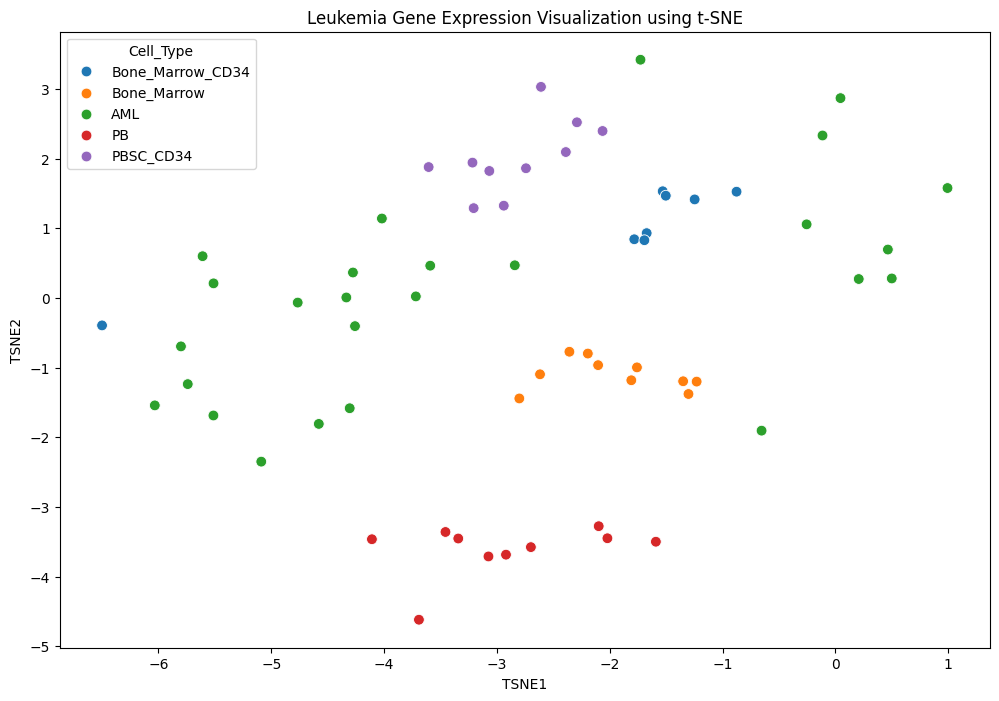

In [17]:
plt.figure(
    figsize=(12,8)
)

sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="Cell_Type",
    s=60
)

plt.title(
    "Leukemia Gene Expression Visualization using t-SNE"
)

plt.show()

In [18]:
tsne_df.to_csv(
    "tsne_gene_expression.csv",
    index=False
)

In [19]:
pickle.dump(
    tsne,
    open(
        "tsne_model.pkl",
        "wb"
    )
)

In [20]:
pickle.dump(
    scaler,
    open(
        "scaler.pkl",
        "wb"
    )
)

In [21]:
print(
    "Original Features:",
    X.shape[1]
)

print(
    "Reduced Features:",
    2
)

reduction = (
    (X.shape[1]-2)
    / X.shape[1]
)*100

print(
    f"Dimensionality Reduction: {reduction:.2f}%"
)

Original Features: 22283
Reduced Features: 2
Dimensionality Reduction: 99.99%
